# 1. Basemaps

Recreates the "1. Basemaps" figures from the R package's
[README](https://github.com/ccamlr/CCAMLRGIS/blob/master/README.md), using
`ccamlrgis` + `ccamlrgis.plot` in place of R's base graphics
(`plot()`/`add_RefGrid()`/`add_Cscale()`/`add_labels()`). All spatial
manipulation happens in the CCAMLR standard CRS, EPSG:6932 (South Pole
Lambert Azimuthal Equal Area).

This notebook calls the live CCAMLR WFS (`load_asds`, `load_eezs`,
`load_coastline`, `load_bathy`) and is not part of the offline test suite --
see `docs/porting_notes.md`.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

import ccamlrgis as cg
import ccamlrgis.plot as cgplot
from ccamlrgis import datasets

depth_cmap = ListedColormap(cg.DEPTH_COLS)
depth_norm = BoundaryNorm(cg.DEPTH_CUTS, depth_cmap.N)

## Bathymetry

The R tutorial downloads a 5km-resolution bathymetry raster via
`load_Bathy(LocalFile=FALSE, Res=5000)`. `load_bathy` caches the download
(`ccamlrgis.cache`), so re-running this cell after the first time reads
from disk.

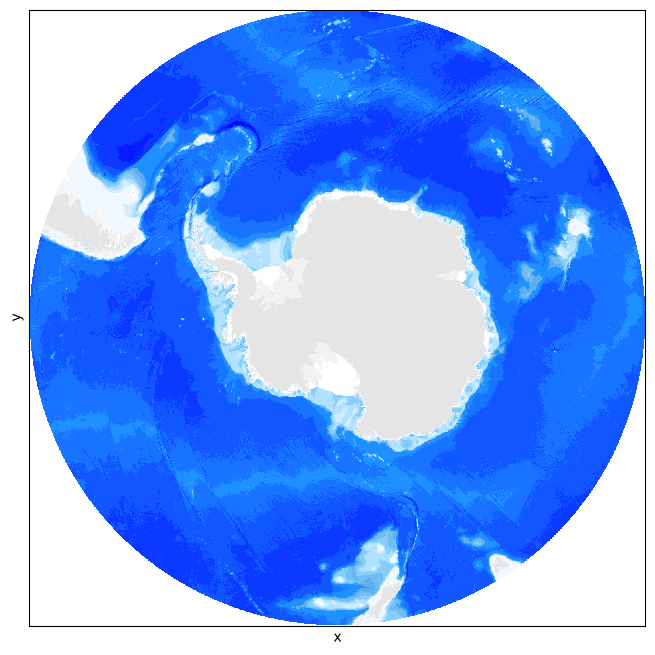

In [2]:
bathy = cg.load_bathy(res=5000)

fig, ax = cgplot.basemap(figsize=(8, 8))
bathy.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
ax.set_title("")
plt.show()

## Statistical Areas, Subareas and Divisions (ASDs)

The bundled low-resolution `small_bathy()` raster (R's `SmallBathy()`)
plus ASD/EEZ boundaries, coastline, a reference grid, a colour scale, and
auto-placed ASD labels.

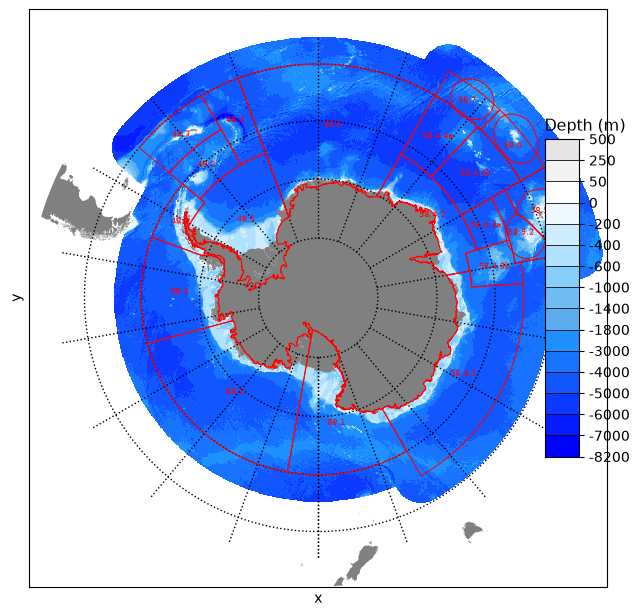

In [3]:
bathy_small = cg.small_bathy()
asds = cg.load_asds()
eezs = cg.load_eezs()
coast = cg.load_coastline()

fig, ax = cgplot.basemap(figsize=(9, 7.5))
bathy_small.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
cgplot.add_reference_grid(ax=ax, res_lat=10, res_lon=20, lab_lon=0, fontsize=7.5)
cgplot.add_colour_scale(ax=ax, cuts=cg.DEPTH_CUTS, cols=cg.DEPTH_COLS, width="6%", height="55%")
asds.boundary.plot(ax=ax, edgecolor="red", linewidth=0.75)
eezs.boundary.plot(ax=ax, edgecolor="red", linewidth=0.75)
coast.plot(ax=ax, color="grey", linewidth=0.01)
cgplot.add_labels(ax=ax, mode="auto", layer="ASDs", fontsize=6, colour="red")
ax.set_title("")
plt.show()

## Local map (e.g., Subarea 48.6)

As in the R tutorial, the coastline for this local map comes from the
bundled `Coast` dataset, subset by its per-ASD `ID` column
(`Coast[Coast$ID=='48.6',]`) -- not the live `load_coastline()` WFS layer,
which has no such per-ASD subset (only a `surface` column: Land / Ice
shelves / Ice tongues / Ice rumples).

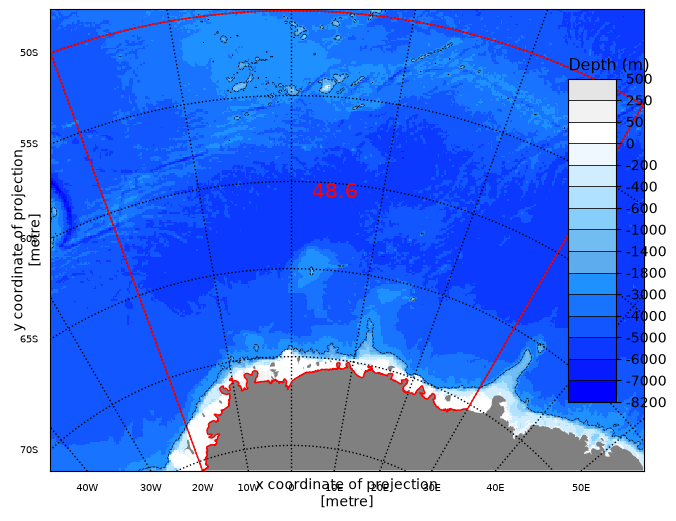

In [4]:
s486 = asds[asds["GAR_Short_Label"] == "486"]
bathy_486 = bathy_small.rio.clip_box(*s486.total_bounds)
coast = datasets.load_example("Coast")
coast_486 = coast[coast["ID"] == "48.6"]
labels = datasets.load_example("Labels")

fig, ax = cgplot.basemap(figsize=(8, 6))
bathy_486.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
cgplot.add_colour_scale(ax=ax, cuts=cg.DEPTH_CUTS, cols=cg.DEPTH_COLS, width="8%", height="70%")
coast_486.plot(ax=ax, color="grey", linewidth=0.01)
cgplot.add_reference_grid(ax=ax, res_lat=5, res_lon=10, fontsize=7.5)
s486.boundary.plot(ax=ax, edgecolor="red", linewidth=1)
bathy_486.plot.contour(ax=ax, levels=[-2000], colors="black", linewidths=0.5)
lab486 = labels[labels["t"] == "48.6"]
ax.text(lab486["x"].iloc[0], lab486["y"].iloc[0], "48.6", color="red", fontsize=15, ha="center", va="center")
ax.set_title("")
plt.show()